# No Flux Boundary Experiments

## Setup

### Liberaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Import custom functions 

In [17]:
from sources.simulation import numerical_solution, euler_maruyama
from sources.plotting import *
from sources.analysis import stationary_solution
from sources.models import *

### Initialization

In [18]:

#defind varaibles

#10 mil
n_parts = 10000000

T = 2
dt = 0.01

n_steps = int(T/ dt)
# epsilon = np.sqrt(dt)

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions

del b, sigma # clean up b and sigma first
b = lambda x, t=None: constant_drift(x, t, value=1)
sigma = lambda x, t=None: constant_diffusion(x, t, value=1)


### Initial distribution

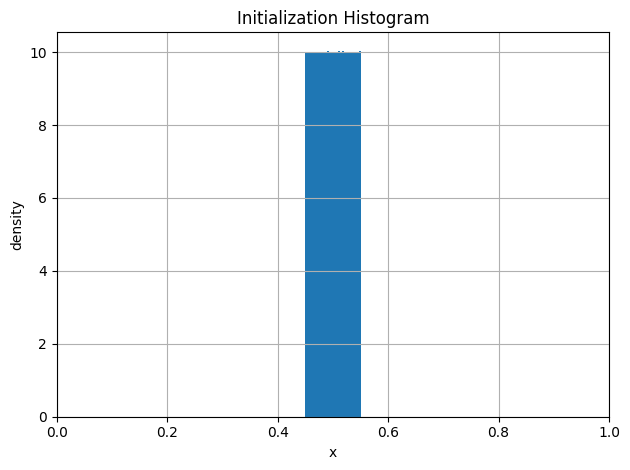

In [19]:
# X_0 = np.random.uniform(bc_1,bc_2, n_parts)
X_0 = np.random.uniform(.45,.55, n_parts)

plot_histogram(X_0, 30, title="Initialization Histogram", x_limit=x_bounds)

plt.tight_layout()
plt.show()

## Experiments

### Compore solutions with reflection, rejection and theta ($\theta =0.5$) boundary conditions

In [20]:


X_ref, _, _ = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=x_bounds, save_every=None)

X_rej, _, _ = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=x_bounds
                                                     , save_every=None)

X_theta, _, _ = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5), boundaries=x_bounds
                                                     , save_every=None)

### Plot the numerical and exact solutions

In [ ]:
#compute the true solution
x_plot = np.linspace(x_bounds(1), 500)
p_exact = stationary_solution(x_plot, b, sigma, (bc_1, bc_2))

# plot full histogram
fig, ax = plt.subplots(1, 2, figsize=(10, 5), sharey=True, sharex=True)

fig.suptitle(fr"Solution distribution for {b=} and $\sigma$={sigma} with {T=}, {dt=}, {n_steps}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)


plt.tight_layout()
plt.show()

